In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "adult"
namex = "Adult"

d = 14

###threshold
graphsx = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)

## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/adult_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),4.0,328,48,12,36,12.695122,3.719512,8.975610,86.750000,4.561858,1.525352,3.036506,6,51,35,0,0
1,Adult (14),4.5,328,49,12,37,19.545732,5.262195,14.283537,130.836735,9.621176,2.785671,6.835505,2,33,21,0,1
2,Adult (14),5.0,328,49,12,37,27.003049,6.871951,20.131098,180.755102,17.002780,4.458725,12.544055,2,20,9,0,2
3,Adult (14),5.5,328,49,12,37,33.466463,8.344512,25.121951,224.020408,24.895193,6.197862,18.697331,0,9,6,0,3
4,Adult (14),6.0,328,49,12,37,38.951220,9.612805,29.338415,260.734694,32.537136,7.907118,24.630018,0,6,2,0,4
5,Adult (14),6.5,328,49,12,37,42.829268,10.585366,32.243902,286.693878,38.457224,9.440442,29.016782,1,4,0,0,5
6,Adult (14),7.0,328,49,12,37,45.698171,11.286585,34.411585,305.897959,43.116991,10.646770,32.470221,0,2,0,0,6
7,Adult (14),7.5,328,49,12,37,47.350610,11.695122,35.655488,316.959184,45.946297,11.404863,34.541434,0,0,0,0,7
8,Adult (14),8.0,328,49,12,37,48.256098,11.887195,36.368902,323.020408,47.579007,11.776535,35.802473,0,0,0,2,8
9,Adult (14),8.5,328,49,12,37,48.698171,11.960366,36.737805,325.979592,48.411520,11.920955,36.490565,0,0,0,6,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=True,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,r,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{5},{5: 1},202.512964,{5},{5: 1},202.512964,206.512964,"[4, 8, 17, 24]",...,"[4, 8, 17, 24]",4,4.0,328,48,0.157572,0.166461,0.154805,adult (14),0
1,1,3,{5},{5: 1},202.512964,{5},{5: 1},202.512964,205.512964,"[4, 8, 17]",...,"[4, 8, 17]",3,4.0,328,48,0.208612,0.270967,0.176772,adult (14),0
2,1,2,{5},{5: 1},202.512964,{5},{5: 1},202.512964,204.512964,"[4, 8]",...,"[4, 8]",2,4.0,328,48,0.178405,0.153851,0.314364,adult (14),0
3,1,1,{5},{5: 1},202.512964,{5},{5: 1},202.512964,203.512964,[4],...,[4],1,4.0,328,48,0.305564,0.273749,0.229621,adult (14),0
4,1,0,{5},{5: 1},202.512964,{5},{5: 1},202.512964,202.512964,[],...,[],0,4.0,328,48,0.275637,0.201988,0.235911,adult (14),0
5,2,4,"{9, 5}","{9: 1, 5: 1}",231.237085,"{9, 5}","{9: 1, 5: 1}",231.237085,235.237085,"[4, 8, 17, 24]",...,"[4, 8, 17, 24]",4,4.0,328,48,0.356446,0.369792,0.347413,adult (14),0
6,2,3,"{9, 5}","{9: 1, 5: 1}",231.237085,"{9, 5}","{9: 1, 5: 1}",231.237085,234.237085,"[4, 8, 17]",...,"[4, 8, 17]",3,4.0,328,48,0.322420,0.329041,0.339965,adult (14),0
7,2,2,"{9, 5}","{9: 1, 5: 1}",231.237085,"{9, 5}","{9: 1, 5: 1}",231.237085,233.237085,"[4, 8]",...,"[4, 8]",2,4.0,328,48,0.312404,0.422022,0.335220,adult (14),0
8,2,1,"{9, 5}","{9: 1, 5: 1}",231.237085,"{9, 5}","{9: 1, 5: 1}",231.237085,232.237085,[4],...,[4],1,4.0,328,48,0.363895,0.415089,0.412193,adult (14),0
9,2,0,"{9, 5}","{9: 1, 5: 1}",231.237085,"{9, 5}","{9: 1, 5: 1}",231.237085,231.237085,[],...,[],0,4.0,328,48,0.327122,0.461202,0.360190,adult (14),0


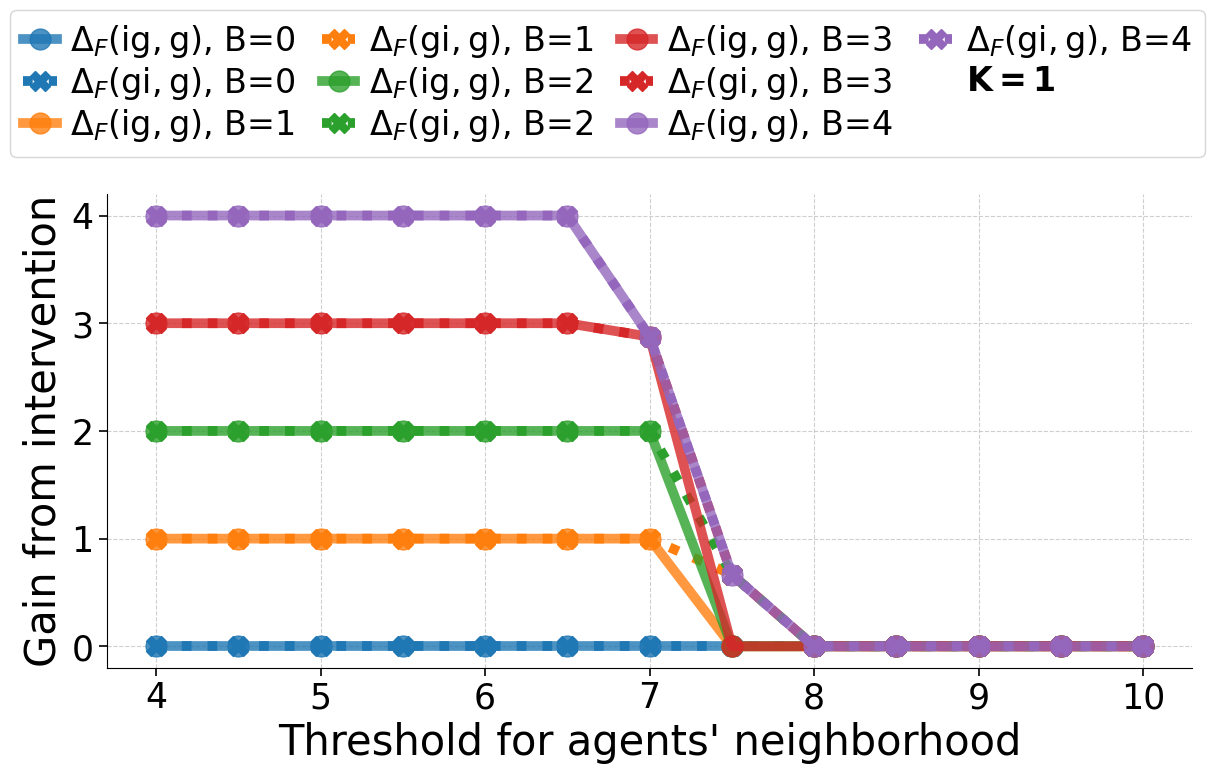

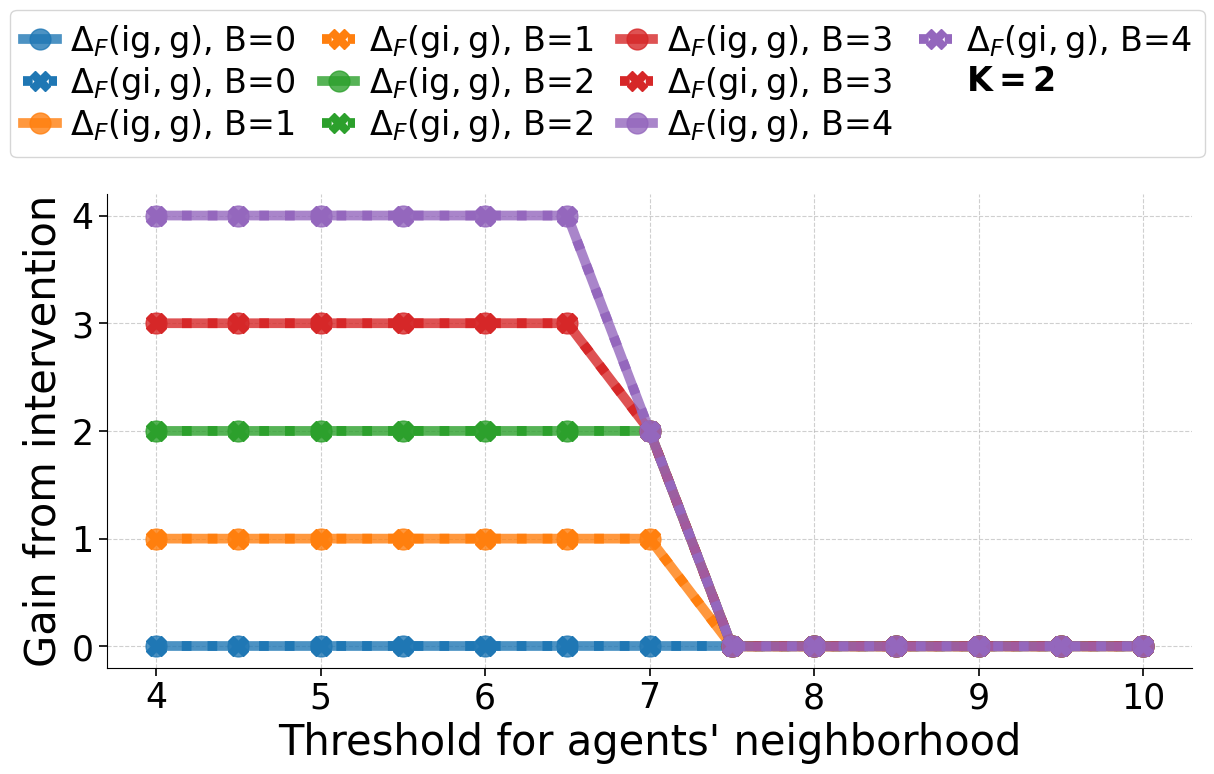

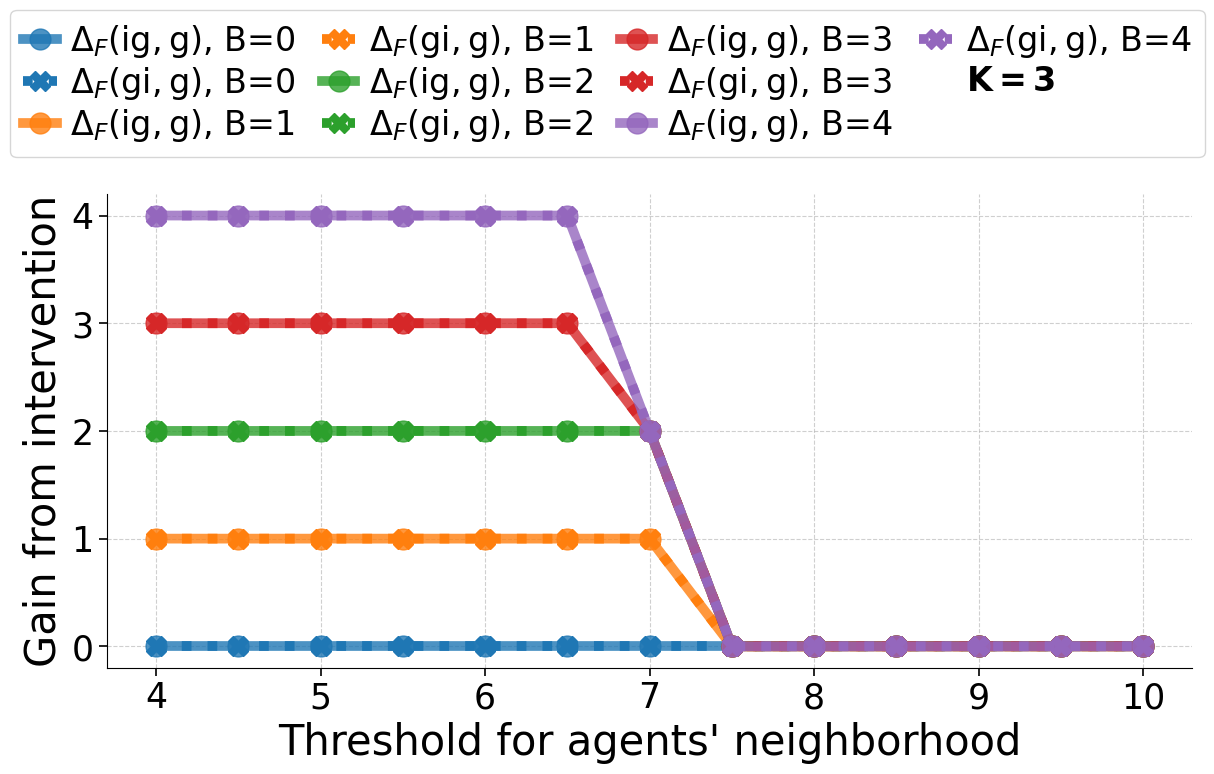

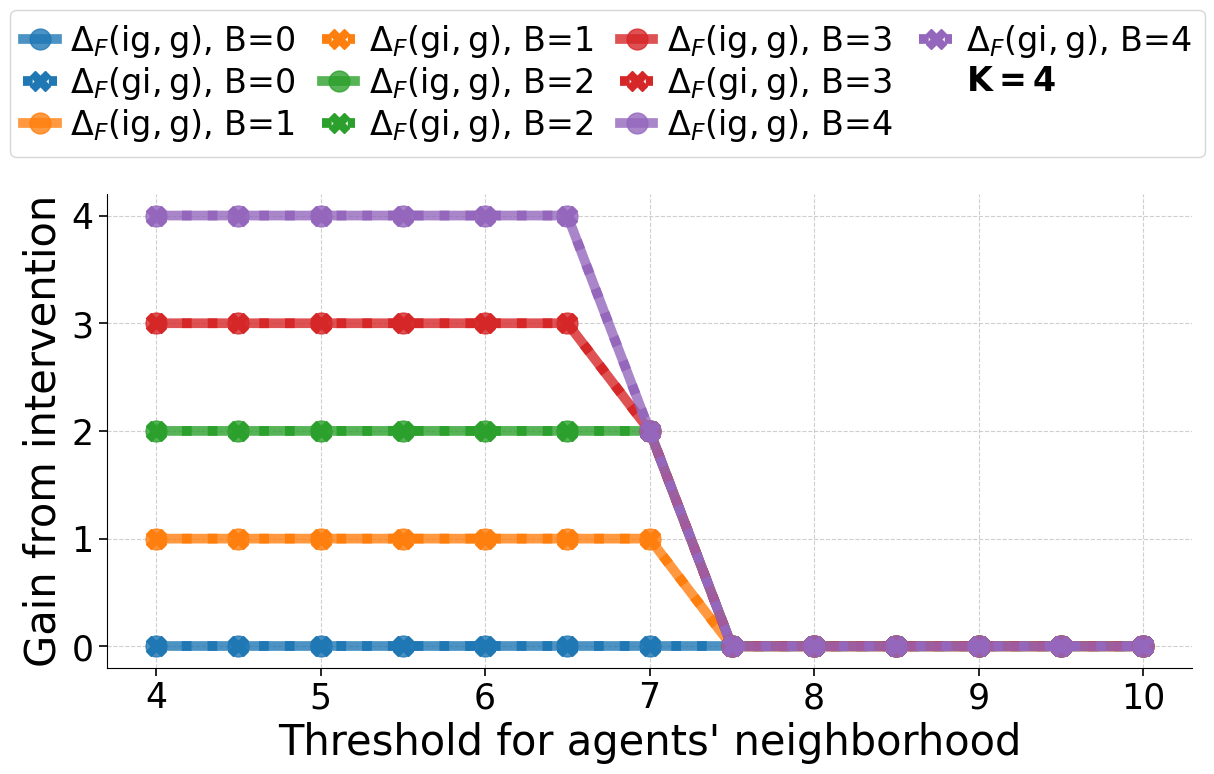

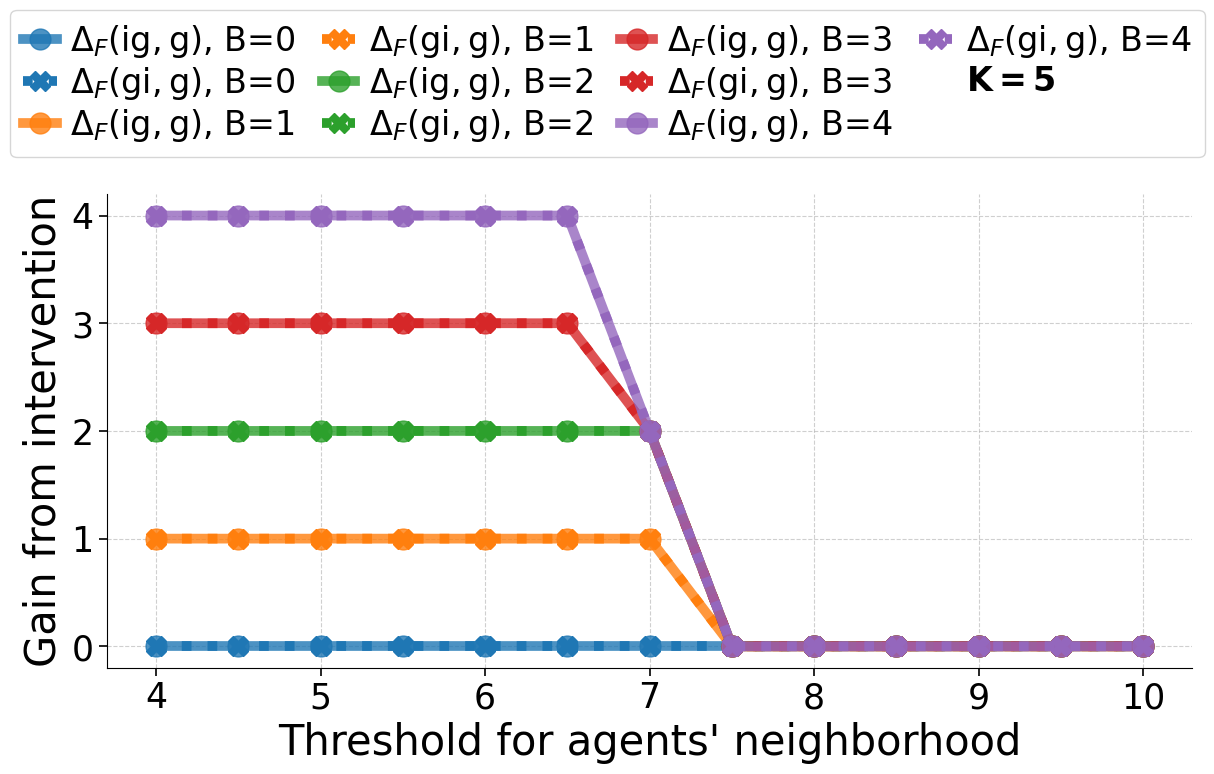

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh = True, 
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_thresh")